# Emotion clasification with LoRA vs QLoRA

**Instrucciones**

En este taller los estudiantes aplicarán LoRA y QLoRA para clasificación de emociones en texto, realizando un grid search sobre los hiperparámetros clave de LoRA y comparando ambas técnicas sobre el mismo modelo base y sobre uno de mayor tamaño.

El objetivo es que desarrollen criterio para elegir entre ambas técnicas según restricciones reales de cómputo, respaldados por métricas concretas de rendimiento, memoria y tiempo de entrenamiento.

Entregar notebook con resultados y reflexión sobre los resultados.

## Setup

In [3]:

import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import gc
import json
import time
import random
import math
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bitsandbytes as bnb
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
from torch.utils.data import DataLoader
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from settings import LOGS_DIR

from peft import (
    LoraConfig, get_peft_model, TaskType,
    prepare_model_for_kbit_training,
    PeftModel
)

gpu_id = 1
device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:        {torch.__version__}")
print(f"bitsandbytes:   {bnb.__version__}")
print(f"Device:         {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:            {p.name}")
    print(f"Total memory:   {p.total_memory/1e9:.1f} GB")

PyTorch:        2.10.0+cu128
bitsandbytes:   0.49.2
Device:         cuda:1
GPU:            NVIDIA H200
Total memory:   150.1 GB


In [4]:
def reset_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def report_memory(label):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(
            f"[{label}] allocated: {allocated:.5f} GB | reserved: {reserved:.2f} GB | peak: {peak:.5f} GB"
        )

## Dataset exploration

Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise.

**Data Fields**

The data fields are:

- text: a string feature.
- label: a classification label, with possible values including sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5).

**Data Splits**

The dataset has 2 configurations:

- split: with a total of 20_000 examples split into train, validation and split
- unsplit: with a total of 416_809 examples in a single train split


In [5]:
dataset = load_dataset("dair-ai/emotion", "split")
print("splits:", dataset.keys())
train_dataset, val_dataset, test_dataset = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

print(f"train: {len(train_dataset)} examples")
print(f"validation: {len(val_dataset)} examples")
print(f"test: {len(test_dataset)} examples")

splits: dict_keys(['train', 'validation', 'test'])
train: 16000 examples
validation: 2000 examples
test: 2000 examples


In [6]:
id_to_label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

In [7]:
train_df = pd.DataFrame(train_dataset.to_dict())
train_df["label_text"] = train_df["label"].map(id_to_label)
train_df.head()

,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


**Label distribution**

There is a clear class imbalance, with "joy" being the most common emotion and "surprise" the least common. Since we are doing fine tunning and not classification via a classification head, we will leave it at that without any data augmentation or class-imbalance correction technique.

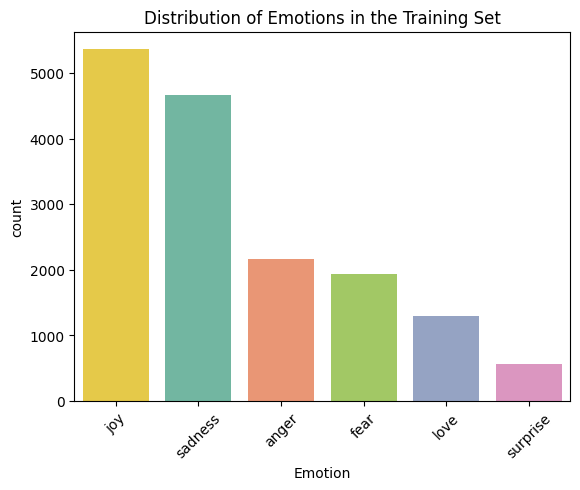

In [8]:
sns.countplot(
    data=train_df,
    x="label_text",
    order=train_df["label_text"].value_counts().index,
    hue="label_text",
    palette="Set2",
)
plt.xlabel("Emotion")
plt.title("Distribution of Emotions in the Training Set")
plt.xticks(rotation=45)
plt.show()

Notes from the future: turns our the dataset is just way too big for our current computation resources, so we will work with a reduced version composed of 20 examples per emotion, both for the training and validation sets. This results in a dataset of size 120, which is fine considering our aim is to compare LoRA vs QLoRA, and not build a state of the art emotion classification model.

In [9]:
from collections import Counter

def select_k_per_label(ds, k=20, label_field="label"):
    counts = Counter()
    indices = []
    for i, ex in enumerate(ds):
        lbl = ex[label_field]
        if counts[lbl] < k:
            indices.append(i)
            counts[lbl] += 1
        if len(counts) == len(id_to_label) and all(v >= k for v in counts.values()):
            break
    return ds.select(indices)

# Create reduced splits
k = 20
train_small = select_k_per_label(train_dataset, k=k)
val_small = select_k_per_label(val_dataset, k=k)
test_small = select_k_per_label(test_dataset, k=k)

print("train_small:", len(train_small))
print("val_small:  ", len(val_small))
print("test_small:  ", len(test_small))
print("train label counts:", Counter(train_small["label"]))
print("val label counts:  ", Counter(val_small["label"]))
print("test label counts:  ", Counter(test_small["label"]))

train_small: 120
val_small:   120
test_small:   120
train label counts: Counter({0: 20, 3: 20, 2: 20, 5: 20, 4: 20, 1: 20})
val label counts:   Counter({0: 20, 2: 20, 3: 20, 1: 20, 4: 20, 5: 20})
test label counts:   Counter({0: 20, 1: 20, 4: 20, 3: 20, 2: 20, 5: 20})


### Dataset adaptation to (question, answer) format

Just like the practice problem, we will train the model to respond in json format. We also create a dataloader to speed up training, otherwise we have to use very small batch sizes.

In [10]:
def qa_template(example):
    return {"q": example["text"], "a": json.dumps({"emotion": id_to_label[example["label"]]})}

# Adapt to (q,a) format using existing qa_template
train_adapted_small = train_small.map(qa_template, remove_columns=train_small.column_names)
val_adapted_small = val_small.map(qa_template, remove_columns=val_small.column_names)
test_adapted_small = test_small.map(qa_template, remove_columns=test_small.column_names)

print(train_adapted_small[0])

{'q': 'i didnt feel humiliated', 'a': '{"emotion": "sadness"}'}


## Loading the model in 4 bits

### 4.1 `BitsAndBytesConfig`

The config object bundles all three QLoRA tricks plus a few practical knobs:

- `load_in_4bit=True` — turn on 4-bit loading for linear layers.
- `bnb_4bit_quant_type="nf4"` — use NF4 (vs `"fp4"`, the older 4-bit float format).
- `bnb_4bit_use_double_quant=True` — double quantization (Section 2.2).
- `bnb_4bit_compute_dtype=torch.bfloat16` — dequantize to bf16 for the matmul. This is *not* the storage dtype; it's what NF4 gets cast to right before the multiply. You want bf16 here for numerical headroom; fp16 sometimes underflows on the rare large activations.

Also note: when loading in 4-bit you can't use `.to(device)` after the fact — you have to pass `device_map` to `from_pretrained` and let `bitsandbytes` place the quantized weights directly.

In [11]:
# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # The only model that fit our GPU, unfortunately there wasn't much memory available at the time of training.

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded tokenizer for {MODEL_NAME}")

Loaded tokenizer for Qwen/Qwen2.5-0.5B-Instruct


In [12]:
def hard_reset():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


hard_reset()


def fresh_model(model_name=MODEL_NAME, quantization=True):
    if quantization:
        bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
        )

        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_cfg,
            device_map="auto",
            dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name, torch_dtype=torch.bfloat16
        ).to(device)

    return model


hard_reset()
nf4_model = fresh_model()
report_memory(f"{MODEL_NAME} in NF4 + DQ")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Qwen/Qwen2.5-0.5B-Instruct in NF4 + DQ] allocated: 0.00000 GB | reserved: 0.00 GB | peak: 0.00000 GB


### 4.2 Side-by-side memory: bf16 vs NF4

Drop the 4-bit model, load the same checkpoint in bf16, measure the peak. The ratio is the cleanest sanity check that quantization actually fired.

In [13]:
del nf4_model
hard_reset()

bf16_model = fresh_model(quantization=False)
report_memory(f"{MODEL_NAME} in bf16")

del bf16_model
hard_reset()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[Qwen/Qwen2.5-0.5B-Instruct in bf16] allocated: 0.00000 GB | reserved: 0.00 GB | peak: 0.00000 GB


## Training the QLoRA adapter
### Tokenization

In [14]:
def tokenize_chat(example, tokenizer, max_len=512):
    """Render chat template, tokenize, mask prompt with -100 (same as class 2)."""
    user_msg = [{"role": "user", "content": example["q"]}]
    full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

    prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
    full_text = tokenizer.apply_chat_template(
        full_msg, add_generation_prompt=False, tokenize=False
    )

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids = tokenizer(full_text, add_special_tokens=False).input_ids[:max_len]

    labels = list(full_ids)
    for i in range(min(len(prompt_ids), len(full_ids))):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


def collate(batch, pad_id):
    """Same padding collator as class 2."""
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"] + [-100] * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids": torch.tensor(ids).to(device),
        "labels": torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }

In [15]:
train_examples = [tokenize_chat(ex, tokenizer) for ex in train_adapted_small]
val_examples = [tokenize_chat(ex, tokenizer) for ex in val_adapted_small]
test_examples = [tokenize_chat(ex, tokenizer) for ex in test_adapted_small]

print(f"Tokenized: {len(train_examples)} train | {len(val_examples)} val | {len(test_examples)} test")

Tokenized: 120 train | 120 val | 120 test


### Training

We first wrap our training model logic in a lightning module, since that will make easier to track performance and test parameter combinations.

In [16]:
DEFAULT_TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
]


class EmotionModel(L.LightningModule):
    def __init__(
        self,
        model_name=MODEL_NAME,
        lr=5e-5,
        r=8,
        lora_dropout=0.0,
        target_modules=DEFAULT_TARGET_MODULES,
        quantization=True,
    ):
        super().__init__()
        self.quantization = quantization
        self.model = fresh_model(model_name, quantization=quantization)
        if quantization:
            self.model = prepare_model_for_kbit_training(self.model)

        cfg = LoraConfig(
            r=r,
            lora_alpha=2 * r,  # A common heuristic is to set alpha to 2x the rank
            target_modules=target_modules,
            lora_dropout=lora_dropout,
            bias="none",
            task_type=TaskType.CAUSAL_LM,
        )
        self.model = get_peft_model(self.model, cfg)
        self.lr = lr

        self.history = {"train_loss": [], "val_loss": []}

        self.save_hyperparameters()

    def forward(self, input_ids, attention_mask=None, labels=None):
        return self.model(
            input_ids=input_ids, attention_mask=attention_mask, labels=labels
        )

    def training_step(self, batch, batch_idx):
        out = self(**batch)
        self.log("train_loss", out.loss, prog_bar=True)
        self.history["train_loss"].append(out.loss.item())
        return out.loss

    def validation_step(self, batch, batch_idx):
        out = self(**batch)
        self.log("val_loss", out.loss, prog_bar=True)
        
        # To prevent the final validation from adding extra steps
        if len(self.history["val_loss"]) <= len(self.history['train_loss']):
            self.history["val_loss"].append(out.loss.item())
        return out.loss

    def configure_optimizers(self):
        return bnb.optim.PagedAdamW8bit(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=self.lr,
            weight_decay=0.0,
        )

    def on_save_checkpoint(self, checkpoint):
        # Filter the state_dict to keep only LoRA weights
        # This prevents saving the entire huge base model
        state_dict = checkpoint["state_dict"]
        filtered_state_dict = {
            k: v
            for k, v in state_dict.items()
            if "lora" in k or "peft" in k or "modules_to_save" in k
        }
        checkpoint["state_dict"] = filtered_state_dict

        save_path = f"{self.trainer.logger.log_dir}/checkpoints"
        self.model.save_pretrained(save_path)
        
    def on_load_checkpoint(self, checkpoint):
        # This tells Lightning: "It's okay that the base model weights are missing 
        # from the checkpoint; just load the adapters."
        self.strict_loading = False


    def plot_training_curves(self):
        window = 5
        plt.figure(figsize=(8, 3.5))
        train_loss_smooth = pd.Series(self.history["train_loss"]).rolling(window).mean()
        val_loss_smooth = pd.Series(self.history["val_loss"]).rolling(window).mean()

        plt.plot(
            self.history["train_loss"], color="tab:blue", alpha=0.25, label="raw_train"
        )
        plt.plot(
            self.history["val_loss"], color="tab:orange", alpha=0.25, label="raw_val"
        )
        plt.plot(
            train_loss_smooth,
            color="tab:blue",
            lw=2,
            label=f"training rolling mean ({window})",
        )
        plt.plot(
            val_loss_smooth,
            color="tab:orange",
            lw=2,
            label=f"validation rolling mean ({window})",
        )
        plt.xlabel("Step")
        plt.ylabel("Cross-entropy")
        plt.title(f"{'QLoRA' if self.quantization else 'LoRA'} learning curves")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

In [17]:
def train_over_grid(
    train_dataloader, val_dataloader, params_grid, quantization=True, epochs=10, patience=2,verbose=True
):
    """Train separate models for each combination of hyperparameters in params_grid. Supports both LoRA and QLoRA based on the quantization flag."""
    results = {}
    param_combinations = [(r, target_modules) for r in params_grid["r"] for target_modules in params_grid["target_modules"]]

    for r, target_modules in param_combinations:
        reset_memory()
        print("\n" + "=" * 80)
        print(
            f"\nTraining with r={r}, target_modules={target_modules}, quantization={'QLoRA' if quantization else 'LoRA'}"
        )
        print("\n" + "=" * 80)

        model = EmotionModel(r=r, target_modules=target_modules, quantization=quantization)
        logger = TensorBoardLogger(
            LOGS_DIR,
            name=f"{'qlora' if quantization else 'lora'}_emotion",
            version=f"r_{r}_tm_{len(target_modules)}",
        )

        # create per-run checkpoint and early stop callbacks (unique for the run)
        ckpt_callback = ModelCheckpoint(
            save_top_k=1,
            monitor="val_loss",
            mode="min",
            filename="best",
            enable_version_counter=False,
        )

        early_stop_callback = EarlyStopping(
            monitor="val_loss",
            min_delta=0.01,
            patience=patience,
            verbose=True,
            mode="min",
        )

        trainer = L.Trainer(
            max_epochs=epochs,
            callbacks=[ckpt_callback, early_stop_callback],
            devices=[gpu_id],
            log_every_n_steps=10,
            enable_progress_bar=False,
            logger=logger,
        )

        # run training
        trainer.fit(model, train_dataloader, val_dataloader)

        # Save the path to the best checkpoint for this run
        best_ckpt_path = ckpt_callback.best_model_path
        print(f"Best checkpoint for r={r}, target_modules={target_modules}: {best_ckpt_path}")

        best_val = ckpt_callback.best_model_score.item()  # best validation loss already tracked
        
        model.cpu() 
        torch.cuda.empty_cache()

        results[(r, len(target_modules))] = {
            "model": model,
            "val_loss": best_val,
            "ckpt_path": best_ckpt_path,
        }
        
        if verbose:
            report_memory(f"r={r}, ,modules={len(target_modules)}")

    return results

In [18]:
num_workers = 0  # Set to 0 to avoid multiprocessing issues
train_dataloader = DataLoader(
    train_examples,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda b: collate(b, tokenizer.pad_token_id),
    num_workers=num_workers,
)
val_dataloader = DataLoader(
    val_examples,
    batch_size=2,
    shuffle=False,
    collate_fn=lambda b: collate(b, tokenizer.pad_token_id),
    num_workers=num_workers,
)
test_dataloader = DataLoader(
    test_examples,
    batch_size=2,
    shuffle=False,
    collate_fn=lambda b: collate(b, tokenizer.pad_token_id),
)

In [19]:
L.seed_everything(0)
torch.set_float32_matmul_precision("medium")

qv_only = ["q_proj", "v_proj"]
attn_all = ["q_proj", "k_proj", "v_proj", "o_proj"]
all_linear = DEFAULT_TARGET_MODULES

# Hyperparm optimization grid
params_grid = {
    "r": [4, 8], 
    "target_modules": [qv_only, attn_all, all_linear]
}

EPOCHS = 10
PATIENCE = 2

Seed set to 0


#### QLoRA grid search

In [20]:
results = train_over_grid(
    train_dataloader,
    val_dataloader,
    params_grid,
    quantization=True,  # QLoRA
    epochs=EPOCHS,
    patience=PATIENCE,
)



Training with r=4, target_modules=['q_proj', 'v_proj'], quantization=QLoRA



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PeftModelForCausalLM │  315 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 270 K                                                                                            
Non-trainable params: 315 M                                                                                        
Total params: 315 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 482                                                                                         
Modules in eval mode: 319                                                                                          
Total FLOPs: 0

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PeftModelForCausalLM │  319 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 315 M                                                                                        
Total params: 319 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 1682                                                                                        
Modules in eval mode: 319                                                                                          
Total FLOPs: 0

Metric val_loss improved. New best score: 0.183
Metric val_loss improved by 0.010 >= min_delta = 0.01. New best score: 0.173
Metric val_loss improved by 0.033 >= min_delta = 0.01. New best score: 0.140
Monitored metric val_loss did not improve in the last 2 records. Best score: 0.140. Signaling Trainer to stop.


Best checkpoint for r=8, target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']: /home/docampor/usfq-mmia/logs/qlora_emotion/r_8_tm_7/checkpoints/best.ckpt
[r=8, ,modules=7] allocated: 0.00001 GB | reserved: 0.03 GB | peak: 1.71844 GB


Best hyperparameters: r=8, target_modules=7, val_loss=0.1399


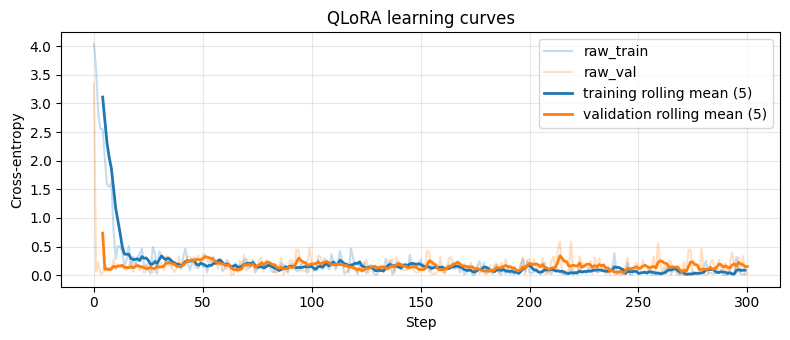

In [21]:
# Best model selection based on validation loss
best_params_qlora = min(results, key=lambda k: results[k]["val_loss"])
final_model_qlora = results[best_params_qlora]["model"]
print(
    f"Best hyperparameters: r={best_params_qlora[0]}, target_modules={best_params_qlora[1]}, val_loss={results[best_params_qlora]['val_loss']:.4f}"
)
final_model_qlora.plot_training_curves()

In [22]:
base_model = fresh_model(quantization=False)  # Load the full base model in bf16
qlora_adapter_dir = results[best_params_qlora]["ckpt_path"].removesuffix("/best.ckpt")
best_model_qlora = PeftModel.from_pretrained(base_model, qlora_adapter_dir, adapter_name="best")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
# Best loss values for each combination of hyperparameters
{k: v["val_loss"] for k, v in results.items()}

{(4, 2): 0.16665321588516235,
 (4, 4): 0.16144756972789764,
 (4, 7): 0.1590314507484436,
 (8, 2): 0.16325712203979492,
 (8, 4): 0.15404416620731354,
 (8, 7): 0.13988779485225677}

#### LoRA grid search

In [23]:
results_lora = train_over_grid(
    train_dataloader,
    val_dataloader,
    params_grid,
    quantization=False,  # LoRA
    epochs=EPOCHS,
    patience=PATIENCE,
)



Training with r=4, target_modules=['q_proj', 'v_proj'], quantization=LoRA



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PeftModelForCausalLM │  494 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 270 K                                                                                            
Non-trainable params: 494 M                                                                                        
Total params: 494 M                                                                                                
Total estimated model params size (MB): 2.0 K                                                                      
Modules in train mode: 482                                                                                         
Modules in eval mode: 319                                                                                          
Total FLOPs: 0

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PeftModelForCausalLM │  498 M │ train │     0 │
└───┴───────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 4.4 M                                                                                            
Non-trainable params: 494 M                                                                                        
Total params: 498 M                                                                                                
Total estimated model params size (MB): 2.0 K                                                                      
Modules in train mode: 1682                                                                                        
Modules in eval mode: 319                                                                                          
Total FLOPs: 0

Metric val_loss improved. New best score: 0.186
Metric val_loss improved by 0.032 >= min_delta = 0.01. New best score: 0.154
Metric val_loss improved by 0.016 >= min_delta = 0.01. New best score: 0.138
Monitored metric val_loss did not improve in the last 2 records. Best score: 0.138. Signaling Trainer to stop.


Best checkpoint for r=8, target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']: /home/docampor/usfq-mmia/logs/lora_emotion/r_8_tm_7/checkpoints/best.ckpt
[r=8, ,modules=7] allocated: 1.01395 GB | reserved: 1.07 GB | peak: 2.88914 GB


Best hyperparameters: r=8, target_modules=7, val_loss=0.1379


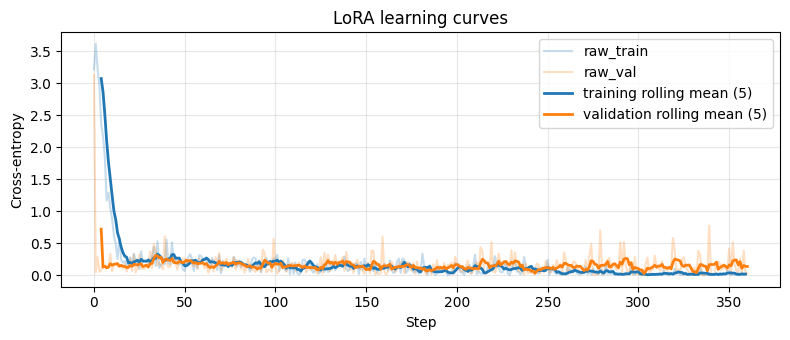

In [24]:
# Best model selection based on validation loss
best_params_lora = min(results_lora, key=lambda k: results_lora[k]["val_loss"])
final_model_lora = results_lora[best_params_lora]["model"]
print(
    f"Best hyperparameters: r={best_params_lora[0]}, target_modules={best_params_lora[1]}, val_loss={results_lora[best_params_lora]['val_loss']:.4f}"
)
final_model_lora.plot_training_curves()

In [25]:
lora_adapter_dir = results_lora[best_params_lora]["ckpt_path"].removesuffix("/best.ckpt")
best_model_lora = PeftModel.from_pretrained(base_model, lora_adapter_dir, adapter_name="best")

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [43]:
# Best loss values for each combination of hyperparameters
{k: v["val_loss"] for k, v in results_lora.items()}

{(4, 2): 0.1670914739370346,
 (4, 4): 0.1564679741859436,
 (4, 7): 0.1538398712873459,
 (8, 2): 0.1633063703775406,
 (8, 4): 0.15281805396080017,
 (8, 7): 0.137925386428833}

## Evaluation

Three evaluations, ordered from cheapest to most concrete:

1. **Generation comparison** — sample from base vs QLoRA on held-out prompts. Eyeball whether the JSON appears.
2. **JSON parse rate** — hard metric. Of the held-out outputs, how many parse to a dict containing both expected keys?
3. **Classification accuracy**: How well did the model perform on the actual classification?

### Generation comparison

In [26]:
# One for each emotion
PROBE = list(select_k_per_label(test_dataset, k=1)['text'])
PROBE

['im feeling rather rotten so im not very ambitious right now',
 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived',
 'i cant walk into a shop anywhere where i do not feel uncomfortable',
 'i felt anger when at the end of a telephone call',
 'i find myself in the odd position of feeling supportive of',
 'i feel a little stunned but can t imagine what the folks who were working in the studio up until this morning are feeling']

In [28]:
def generate(model, prompt, max_new_tokens=80, use_adapter=True):
    model.eval()
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(device)
    if use_adapter:
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    else:
        with torch.no_grad(), model.disable_adapter():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

for p in PROBE:
    base_out  = generate(best_model_lora, p, use_adapter=False)
    lora_out = generate(best_model_lora, p, use_adapter=True)
    qlora_out = generate(best_model_qlora, p, use_adapter=True)
    print("-" * 80)
    print(f"PROMPT: {p}")
    print(f"BASE:   {base_out[:160]}")
    print(f"QLORA:  {qlora_out[:160]}")
    print(f"LORA:   {lora_out[:160]}")
print("-" * 80)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--------------------------------------------------------------------------------
PROMPT: im feeling rather rotten so im not very ambitious right now
BASE:   I'm sorry to hear that you're feeling this way. It's important to remember that everyone experiences ups and downs in their lives, and it's perfectly normal to 
QLORA:  {"emotion": "anger"}
LORA:   {"emotion": "anger"}
--------------------------------------------------------------------------------
PROMPT: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
BASE:   That's quite an encouraging message! It sounds like you're feeling positive about your situation after leaving behind some beautiful flowers. Tulips are known f
QLORA:  {"emotion": "joy"}
LORA:   {"emotion": "joy"}
--------------------------------------------------------------------------------
PROMPT: i cant walk into a shop anywhere where i do not feel uncomfortable
BASE:   I'm sorry to hear that you're expe

### JSON parse rate

The eyeball check is reassuring; a hard metric is better. Define success as: the output parses as JSON, *and* it has the two required keys.

In [29]:
def parses_to_schema(text):
    """Output must be valid JSON dict with the 'emotion' key."""
    try:
        obj = json.loads(text)
    except (json.JSONDecodeError, TypeError):
        return False
    return isinstance(obj, dict) and "emotion" in obj


base_ok, qlora_ok, lora_ok = 0, 0, 0
for ex in test_adapted_small:
    base_out  = generate(best_model_lora, ex["q"], use_adapter=False)
    qlora_out = generate(best_model_qlora, ex["q"], use_adapter=True)
    lora_out = generate(best_model_lora, ex["q"], use_adapter=True)
    if parses_to_schema(base_out):  base_ok  += 1
    if parses_to_schema(qlora_out): qlora_ok += 1
    if parses_to_schema(lora_out):  lora_ok  += 1

n = len(test_adapted_small)
print(f"Held-out JSON parse rate (base):   {base_ok}/{n}  ({100*base_ok/n:.0f}%)")
print(f"Held-out JSON parse rate (QLoRA):  {qlora_ok}/{n}  ({100*qlora_ok/n:.0f}%)")
print(f"Held-out JSON parse rate (LoRA):   {lora_ok}/{n}  ({100*lora_ok/n:.0f}%)")

Held-out JSON parse rate (base):   0/120  (0%)
Held-out JSON parse rate (QLoRA):  120/120  (100%)
Held-out JSON parse rate (LoRA):   120/120  (100%)


### Accuracy evaluation

In [34]:
def gen_json_answer(model, prompt, max_new_tokens=80):
    inputs = tokenizer.apply_chat_template(
        [{"role":"user","content":prompt}],
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    text = tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()
    try:
        return json.loads(text)
    except Exception:
        return None

def accuracy_for_model(model, dataset):
    correct = 0
    for ex in dataset:
        pred = gen_json_answer(model, ex["text"])
        pred_label = pred.get("emotion") if isinstance(pred, dict) else None
        if pred_label == id_to_label[ex["label"]]:
            correct += 1
    return correct, len(dataset), correct / len(dataset)

q_correct, n, q_acc = accuracy_for_model(best_model_qlora, test_small)
l_correct, _, l_acc = accuracy_for_model(best_model_lora, test_small)

print(f"QLoRA accuracy: {q_acc:.3f} ({q_correct}/{n})")
print(f"LoRA  accuracy: {l_acc:.3f} ({l_correct}/{n})")

QLoRA accuracy: 0.583 (70/120)
LoRA  accuracy: 0.583 (70/120)


## Final comments
- Peak memory usage stayed around or bellow 1.7 GB the whole process for QLoRA, quite manageable even for a model of considerable size. For LoRA is was around 2.8 GB, so for bigger models it might end up being restrictive.
- Both variants achieved the lowest loss with the same hyperparameters: r = 8 and all linear layers as target modules. The differences in the best losses of each combination appear minimal though, so ideally we should expand the search grid to see if we get more significant loss reductions. 
- Both variants parsed the responses into json perfectly.
- Both variants obtained exactly the same accuracy on the test set. This points to the fact that quantization has minimal impact on how good fine tunning is, which in this case means no loss of accuracy.
- Each hyperparameter combination yielded a very similar best loss for both model variants, further supporting the previous affirmation.
- Reasonably, the model is actually quite low, less than 60%. This is to be expected, considering we used an extremely reduced version of the dataset to overcome the memory constraints (someone seems to be running to many heavy scripts on the GPUs). With some extra time and using all available gpus I would have expected the results to be much better.
- Somehow, the QLoRA grid search took longer to excecute than the LoRA search. I can't make sense of this, only the possible fluctations of the GPU memory availability come to mind as a possible cause.